# CVAI - SW 05 - Do - Exercise

In [2]:
import numpy as np
import matplotlib.pyplot as pl
import cv2 as cv

## Exercise 1: Hough Transformation

Use the Hough transform to detect lines in the following image:

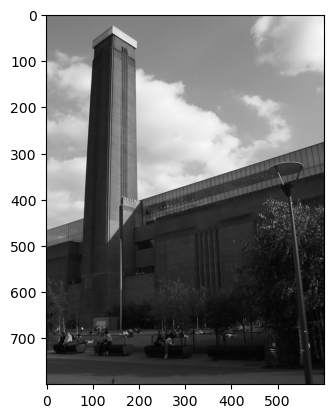

In [4]:
img1 = cv.imread ('Images/LondonSmall.png')
pl.imshow (img1)

Different implementations are available. In OpenCV you may use `HoughLines` to compute the lines found directly. 

https://docs.opencv.org/3.4/dd/d1a/group__imgproc__feature.html

The Implementation from skimage.transform is performed in 2 steps: `hough_lines` computes the accumulator
and `hough_lines_peaks` finds the maxima. Using this implementation enables you to plot the accumulator.

Use `HoughLines` to detect the lines in an edge image. Plot your results and the accumulator.

In [5]:
edg = cv.Canny(img1, 50, 150, apertureSize=3)

# Apply Hough Transform: here, 1 pixel for rho, 1 degree for theta, and a threshold of 100.
lines = cv.HoughLines(edg, 1, np.pi/180, 100)

# Draw the detected lines on the image
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Determine endpoints for the line segment
        pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
        pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))
        cv.line(img1, pt1, pt2, (0, 0, 255), 2)



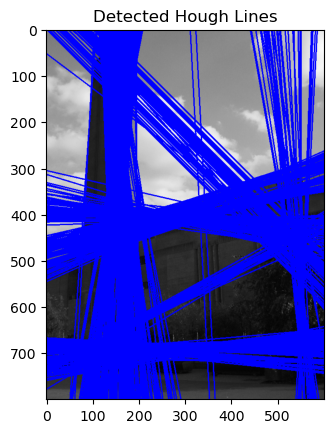

In [6]:
# Display the result
pl.imshow(img1, cmap='gray')
pl.title("Detected Hough Lines")
pl.show()

Plot the lines found by the Hough transform directly onto the image. You will find an example on

http://scikit-image.org/docs/dev/auto_examples/edges/plot_line_hough_transform.html#sphx-glr-auto-examples-edges-plot-line-hough-transform-py

You should convert polar coordinates into cartesian coordinates and calculate the endpoints of the lines.


In [ ]:
...

## Exercise 2: SIFT Feature Extraction and Matching

First we want to extract SIFT features from an image and visualize them. Do this for the following image. Refer to the tutorial here:

https://docs.opencv.org/3.4/db/d27/tutorial_py_table_of_contents_feature2d.html

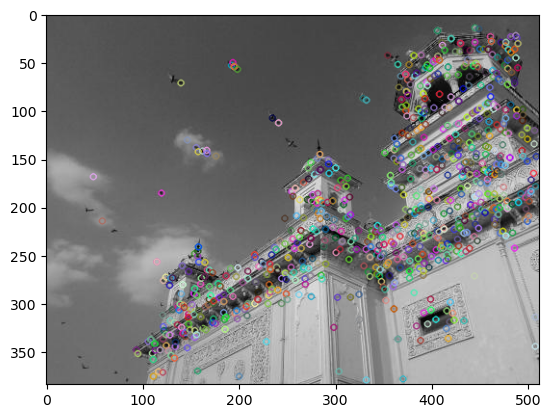

In [3]:
img = cv.imread ('Images/home.jpg')
gray = cv.cvtColor (img,cv.COLOR_BGR2GRAY)

sift = cv.SIFT_create()
kp = sift.detect (gray, None)

img = cv.drawKeypoints (gray,kp,img)
cv.imwrite ('sift_keypoints.jpg', img)
pl.imshow (img)

Second we want to match corresponding features in two images using a brute-force matcher.

Refer to the tutorial https://docs.opencv.org/3.4/dc/dc3/tutorial_py_matcher.html

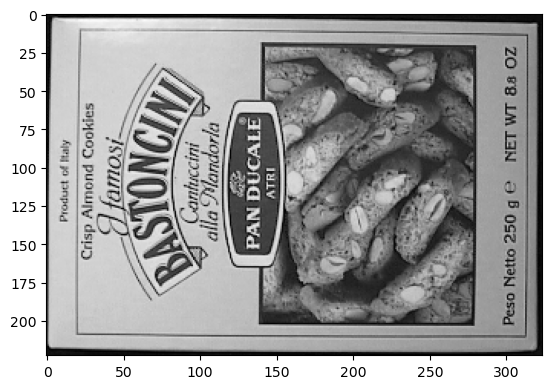

In [4]:
img1 = cv.imread ('Images/box.png', cv.IMREAD_GRAYSCALE)
pl.imshow (img1, cmap = 'gray')

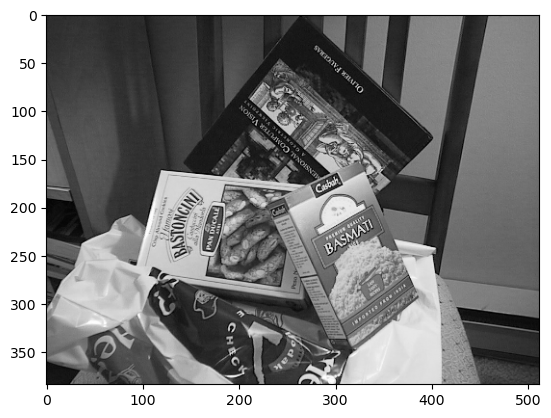

In [5]:
img2 = cv.imread ('Images/box_in_scene.png', cv.IMREAD_GRAYSCALE)
pl.imshow (img2, cmap = 'gray')

In [8]:
# Initiate SIFT detector
sift = cv.SIFT_create()

In [9]:
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2, None)

In [10]:
# BFMatcher with default params
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True)

In [11]:
# Apply ratio test
bf = cv.BFMatcher()

#wir nehmen die zwei besten matches aus des1 
knn_matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

#ein match wird nur dann als good_match genommen, wenn er deutlich besser ist als der zweitbeste match
for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append([m])  




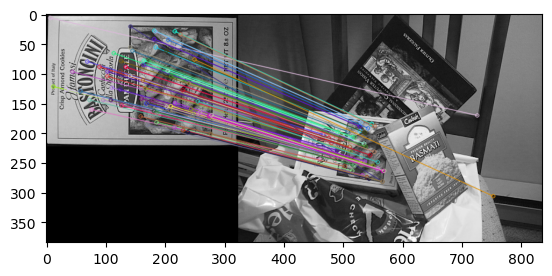

In [14]:
# draw matches onto image
matched_image = cv.drawMatchesKnn(img1, kp1, img2, kp2, good_matches, None, flags=2)
pl.imshow(matched_image)